In [155]:
# Cell 1: Imports + helpers

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba


def _find_matching_file(folder: Path, sample_id: str, exts=(".npz", ".png", ".jpg", ".jpeg", ".tif", ".tiff")):
    """
    Find a file in `folder` whose stem matches `sample_id`.
    """
    for ext in exts:
        p = folder / f"{sample_id}{ext}"
        if p.exists():
            return p
    # fallback: try contains-match (useful if IDs are embedded)
    candidates = []
    for p in folder.iterdir():
        if p.is_file() and p.suffix.lower() in exts and sample_id in p.stem:
            candidates.append(p)
    if len(candidates) == 1:
        return candidates[0]
    return None


def _load_npz_array(npz_path: Path):
    """
    Robust loader for .npz. Tries common keys first, then falls back to first array.
    """
    data = np.load(npz_path, allow_pickle=True)
    preferred_keys = [
        "mask", "pred", "prediction", "seg", "segmentation",
        "gt", "label", "labels", "arr_0", "image", "img"
    ]
    for k in preferred_keys:
        if k in data:
            return data[k]
    # fallback to first key
    if len(data.files) == 0:
        raise ValueError(f"No arrays found in {npz_path}")
    return data[data.files[0]]


def load_mask_any(path: Path):
    """
    Load a segmentation mask from .npz or image file.
    Returns HxW integer mask.
    """
    suffix = path.suffix.lower()

    if suffix == ".npz":
        arr = _load_npz_array(path)
    else:
        from PIL import Image
        arr = np.array(Image.open(path))

    arr = np.asarray(arr)

    # Handle one-hot / logits style arrays
    if arr.ndim == 3:
        # Common possibilities:
        # (C,H,W) or (H,W,C)
        if arr.shape[0] <= 10 and arr.shape[1] > 16 and arr.shape[2] > 16:
            # likely (C,H,W)
            arr = np.argmax(arr, axis=0)
        elif arr.shape[-1] <= 10 and arr.shape[0] > 16 and arr.shape[1] > 16:
            # likely (H,W,C)
            arr = np.argmax(arr, axis=-1)
        else:
            # If it is RGB mask image, try first channel (or customize later)
            arr = arr[..., 0]

    if arr.ndim != 2:
        raise ValueError(f"Expected 2D mask after loading, got shape {arr.shape} from {path}")

    return arr.astype(np.int32)


def load_image_any(path: Path):
    """
    Load an image from .npz or regular image file.
    Returns HxWx3 uint8 image.
    """
    suffix = path.suffix.lower()

    if suffix == ".npz":
        arr = _load_npz_array(path)
    else:
        from PIL import Image
        arr = np.array(Image.open(path))

    arr = np.asarray(arr)

    # Handle grayscale
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)

    # Handle channel-first
    if arr.ndim == 3 and arr.shape[0] in (1, 3) and arr.shape[-1] not in (1, 3):
        arr = np.moveaxis(arr, 0, -1)

    # If single-channel in last dim
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = np.repeat(arr, 3, axis=-1)

    if arr.ndim != 3 or arr.shape[-1] != 3:
        raise ValueError(f"Expected HxWx3 image, got shape {arr.shape} from {path}")

    # Normalize to uint8 if needed
    if arr.dtype != np.uint8:
        arr = arr.astype(np.float32)
        if arr.max() <= 1.0:
            arr = (arr * 255.0).clip(0, 255)
        else:
            arr = arr.clip(0, 255)
        arr = arr.astype(np.uint8)

    return arr


def make_overlay_rgba(mask, class_colors, alpha=0.45, ignore_labels=None):
    """
    Build an RGBA overlay image from an integer mask.
    class_colors: dict {class_id: color_string_or_rgb}
    """
    if ignore_labels is None:
        ignore_labels = set()
    else:
        ignore_labels = set(ignore_labels)

    h, w = mask.shape
    overlay = np.zeros((h, w, 4), dtype=np.float32)

    for cls_id, color in class_colors.items():
        if cls_id in ignore_labels:
            continue
        rgba = to_rgba(color, alpha=alpha)
        overlay[mask == cls_id] = rgba

    return overlay


def collect_common_ids(
    base_root,
    gt_dir,
    img_dir,
    lora_pcts=("2.5", "10", "100"),
    fft_pcts=("2.5", "10", "100"),
    image_exts=(".npz", ".png", ".jpg", ".jpeg", ".tif", ".tiff"),
    mask_exts=(".npz", ".png", ".jpg", ".jpeg", ".tif", ".tiff"),
):
    """
    Returns IDs that exist in all required locations.
    """
    base_root = Path(base_root)
    gt_dir = Path(gt_dir)
    img_dir = Path(img_dir)

    required_dirs = [
        base_root / "zs",
        base_root / "lora" / str(lora_pcts[0]),
        base_root / "lora" / str(lora_pcts[1]),
        base_root / "lora" / str(lora_pcts[2]),
        base_root / "fft" / str(fft_pcts[0]),
        base_root / "fft" / str(fft_pcts[1]),
        base_root / "fft" / str(fft_pcts[2]),
        gt_dir,
        img_dir,
    ]

    # Start with IDs from zs folder
    zs_dir = required_dirs[0]
    ids = set()
    for p in zs_dir.iterdir():
        if p.is_file() and p.suffix.lower() in set(mask_exts):
            ids.add(p.stem)

    # Intersect with each required folder by stem match
    for d in required_dirs[1:]:
        present = set()
        for p in d.iterdir():
            if p.is_file():
                if d == img_dir and p.suffix.lower() in set(image_exts):
                    present.add(p.stem)
                elif d != img_dir and p.suffix.lower() in set(mask_exts):
                    present.add(p.stem)
        ids &= present

    return sorted(ids)

In [156]:
# Cell 2: Main plotting function

def plot_clipseg_overlay_grid(
    base_root,
    gt_dir,
    img_dir,
    selected_ids=None,       # explicit list of sample IDs (recommended)
    n_rows=5,                # used when selected_ids is None
    lora_pcts=("2.5", "10", "100"),
    fft_pcts=("2.5", "10", "100"),
    class_colors=None,       # dict: {0: "black", 1: "tab:blue", ...}
    class_names=None,        # dict: {0: "Clear", 1: "Thick Cloud", ...}
    overlay_alpha=0.45,
    ignore_labels=None,      # e.g., [255] if your masks have ignore index
    show_legend=True,
    legend_loc="lower center",
    legend_ncol=4,
    legend_fontsize=10,
    figsize_per_cell=(3.0, 3.0),  # width, height per subplot
    raw_image_title="image",
    gt_title="ground truth",
    use_ax_annotate_for_headers=True,
    header_annotate_xy=(0.5, 1.07),   # axes fraction coordinates
    header_fontsize=12,
    row_label_mode="id",     # "id" or None
    row_label_fontsize=10,
    row_label_rotation=90,
    show_ticks=False,
    x_ticks=None,            # list like [0, 128, 256, 384, 511]
    y_ticks=None,
    tick_fontsize=8,
    global_xlabel=None,
    global_ylabel=None,
    sup_title=None,
    sup_title_fontsize=14,
    tight_layout_rect=(0, 0.04, 1, 0.96),  # room for legend/title
    interpolation="nearest",
):
    base_root = Path(base_root)
    gt_dir = Path(gt_dir)
    img_dir = Path(img_dir)

    # Default color map (edit this if your class IDs differ)
    if class_colors is None:
        class_colors = {
            0: "tab:blue",    # Clear (example)
            1: "tab:gray",    # Thick Cloud
            2: "gold",        # Thin Cloud
            3: "tab:purple",  # Cloud Shadow
        }

    if class_names is None:
        class_names = {k: f"class {k}" for k in class_colors.keys()}

    # Column definitions in the exact order you requested
    col_specs = [
        ("(a) ZS",        base_root / "zs", None),
        ("(b) LoRA (2.5%)", base_root / "lora" / str(lora_pcts[0]), None),
        ("(c) LoRA (10%)", base_root / "lora" / str(lora_pcts[1]), None),
        ("(d) LoRA (100%)", base_root / "lora" / str(lora_pcts[2]), None),
        ("(e) FFT (2.5%)",  base_root / "fft" / str(fft_pcts[0]),  None),
        ("(f) FFT (10%)",  base_root / "fft" / str(fft_pcts[1]),  None),
        ("(g) FFT (100%)",  base_root / "fft" / str(fft_pcts[2]),  None),
        ("(h) GT",    gt_dir, "gt"),
        ("(i) IMG", img_dir, "image"),
    ]

    # Decide IDs
    if selected_ids is None:
        common_ids = collect_common_ids(
            base_root=base_root,
            gt_dir=gt_dir,
            img_dir=img_dir,
            lora_pcts=lora_pcts,
            fft_pcts=fft_pcts,
        )
        if len(common_ids) == 0:
            raise ValueError("No common sample IDs found across zs/lora/fft/gt/image folders.")
        selected_ids = common_ids[:n_rows]
    else:
        selected_ids = list(selected_ids)
        if n_rows is not None:
            selected_ids = selected_ids[:n_rows]

    n_rows_actual = len(selected_ids)
    n_cols = len(col_specs)

    fig_w = figsize_per_cell[0] * n_cols
    fig_h = figsize_per_cell[1] * n_rows_actual
    fig, axes = plt.subplots(n_rows_actual, n_cols, figsize=(fig_w, fig_h), squeeze=False)

    for r, sample_id in enumerate(selected_ids):
        # Load base image once per row
        img_file = _find_matching_file(img_dir, sample_id)
        if img_file is None:
            raise FileNotFoundError(f"Could not find image for ID '{sample_id}' in {img_dir}")
        img = load_image_any(img_file)

        for c, (col_label, folder, kind) in enumerate(col_specs):
            ax = axes[r, c]

            # Always show image background first
            ax.imshow(img, interpolation=interpolation)

            if kind == "image":
                # raw image only (no overlay)
                pass
            else:
                mask_file = _find_matching_file(folder, sample_id)
                if mask_file is None:
                    raise FileNotFoundError(f"Could not find mask for ID '{sample_id}' in {folder}")

                mask = load_mask_any(mask_file)

                # Safety check for shape mismatch
                if mask.shape[:2] != img.shape[:2]:
                    raise ValueError(
                        f"Shape mismatch for ID '{sample_id}' in column '{col_label}': "
                        f"image {img.shape[:2]} vs mask {mask.shape[:2]}"
                    )

                overlay = make_overlay_rgba(
                    mask=mask,
                    class_colors=class_colors,
                    alpha=overlay_alpha,
                    ignore_labels=ignore_labels,
                )
                ax.imshow(overlay, interpolation=interpolation)

            # Ticks control
            if show_ticks:
                if x_ticks is not None:
                    ax.set_xticks(x_ticks)
                if y_ticks is not None:
                    ax.set_yticks(y_ticks)
                ax.tick_params(axis="both", labelsize=tick_fontsize)
            else:
                ax.set_xticks([])
                ax.set_yticks([])

            # Column headers using ax.annotate (top row only)
            if r == n_rows_actual - 1 and use_ax_annotate_for_headers:
                ax.annotate(
                    col_label,
                    xy=header_annotate_xy,
                    xycoords="axes fraction",
                    ha="center",
                    va="top",
                    fontsize=header_fontsize,
                    fontweight="normal"
                )
            elif r == 0 and not use_ax_annotate_for_headers:
                ax.set_title(col_label, fontsize=header_fontsize, fontweight="bold")

            # Row label (left-most column only)
            if c == 0 and row_label_mode == "id":
                ax.set_ylabel(
                    str(sample_id),
                    fontsize=row_label_fontsize,
                    rotation=row_label_rotation,
                    labelpad=14
                )

    # Global axis labels (optional)
    if global_xlabel is not None:
        fig.supxlabel(global_xlabel)
    if global_ylabel is not None:
        fig.supylabel(global_ylabel)

    if sup_title is not None:
        fig.suptitle(sup_title, fontsize=sup_title_fontsize, y=0.995)

    # Legend (class overlay colors)
    if show_legend:
        handles = []
        for cls_id, color in class_colors.items():
            if ignore_labels is not None and cls_id in set(ignore_labels):
                continue
            label = class_names.get(cls_id, f"class {cls_id}")
            handles.append(mpatches.Patch(color=color, label=f"{label}"))
        if handles:
            fig.legend(
                handles=handles,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.995),  # top center
                ncol=4,
                fontsize=legend_fontsize,
                frameon=True
            )

    plt.tight_layout(rect=tight_layout_rect)
    fig.subplots_adjust(wspace=-0.6)
    plt.show()

In [157]:
# Cell 3: Config (EDIT THIS)

# Root folder that contains:
#   fft/10, fft/100, fft/2.5
#   lora/10, lora/100, lora/2.5
#   zs/
BASE_ROOT = Path("../inference/samples").expanduser().resolve()

# Ground-truth masks folder (contains masks with same IDs as predictions)
GT_DIR = Path("../data/cloudsen12plus/export_p509_high_npz/test/masks").expanduser().resolve()

# Images folder (contains original images with same IDs)
IMG_DIR = Path("../data/cloudsen12plus/export_p509_high_npz/test/images").expanduser().resolve()


# --- Selection controls ---
# Option A: Let it auto-pick first N common IDs
SELECTED_IDS = ["ROI_0792__20190606T074619_20190606T081648_T35JPM", "ROI_0503__20190319T190109_20190319T191114_T10TDK", "ROI_1140__20190106T105431_20190106T110544_T29QPV", "ROI_3652__20200309T101021_20200309T101020_T32SME", "ROI_0064__20181217T015619_20181217T020219_T51JVH"]
N_ROWS = 5


# --- Label/color controls ---
# IMPORTANT: adjust class IDs to match your dataset encoding
CLASS_COLORS = {
    0: "deepskyblue",  # Clear
    1: "tomato",       # Thick cloud
    2: "gold",         # Thin cloud
    3: "limegreen",    # Cloud shadow
    # 255: "black",    # optional ignore class if you want to visualize it (usually ignore instead)
}

CLASS_NAMES = {
    0: "Clear",
    1: "Thick Cloud",
    2: "Thin Cloud",
    3: "Cloud Shadow",
}

IGNORE_LABELS = [255]   # set to None if not needed


# --- Tick / axis controls ---
SHOW_TICKS = False
X_TICKS = [0, 128, 256, 384, 511]  # only used if SHOW_TICKS=True
Y_TICKS = [0, 128, 256, 384, 511]

GLOBAL_XLABEL = None   # e.g. "Width (pixels)"
GLOBAL_YLABEL = None   # e.g. "Sample ID"

In [158]:
import random

RANDOM_SELECT = False
RANDOM_SEED = 16  # change this if you want a different random set

if SELECTED_IDS is None:
    _all_common = collect_common_ids(
        base_root=BASE_ROOT,
        gt_dir=GT_DIR,
        img_dir=IMG_DIR,
        lora_pcts=("2.5", "10", "100"),
        fft_pcts=("2.5", "10", "100"),
    )

    if RANDOM_SELECT:
        rng = random.Random(RANDOM_SEED)
        _selected_now = rng.sample(_all_common, k=min(N_ROWS, len(_all_common)))
    else:
        _selected_now = _all_common[:N_ROWS]
else:
    _selected_now = list(SELECTED_IDS[:N_ROWS])

print("Selected IDs for plotting:")
for i, sid in enumerate(_selected_now, 1):
    print(f"{i}. {sid}")

Selected IDs for plotting:
1. ROI_0792__20190606T074619_20190606T081648_T35JPM
2. ROI_0503__20190319T190109_20190319T191114_T10TDK
3. ROI_1140__20190106T105431_20190106T110544_T29QPV
4. ROI_3652__20200309T101021_20200309T101020_T32SME
5. ROI_0064__20181217T015619_20181217T020219_T51JVH


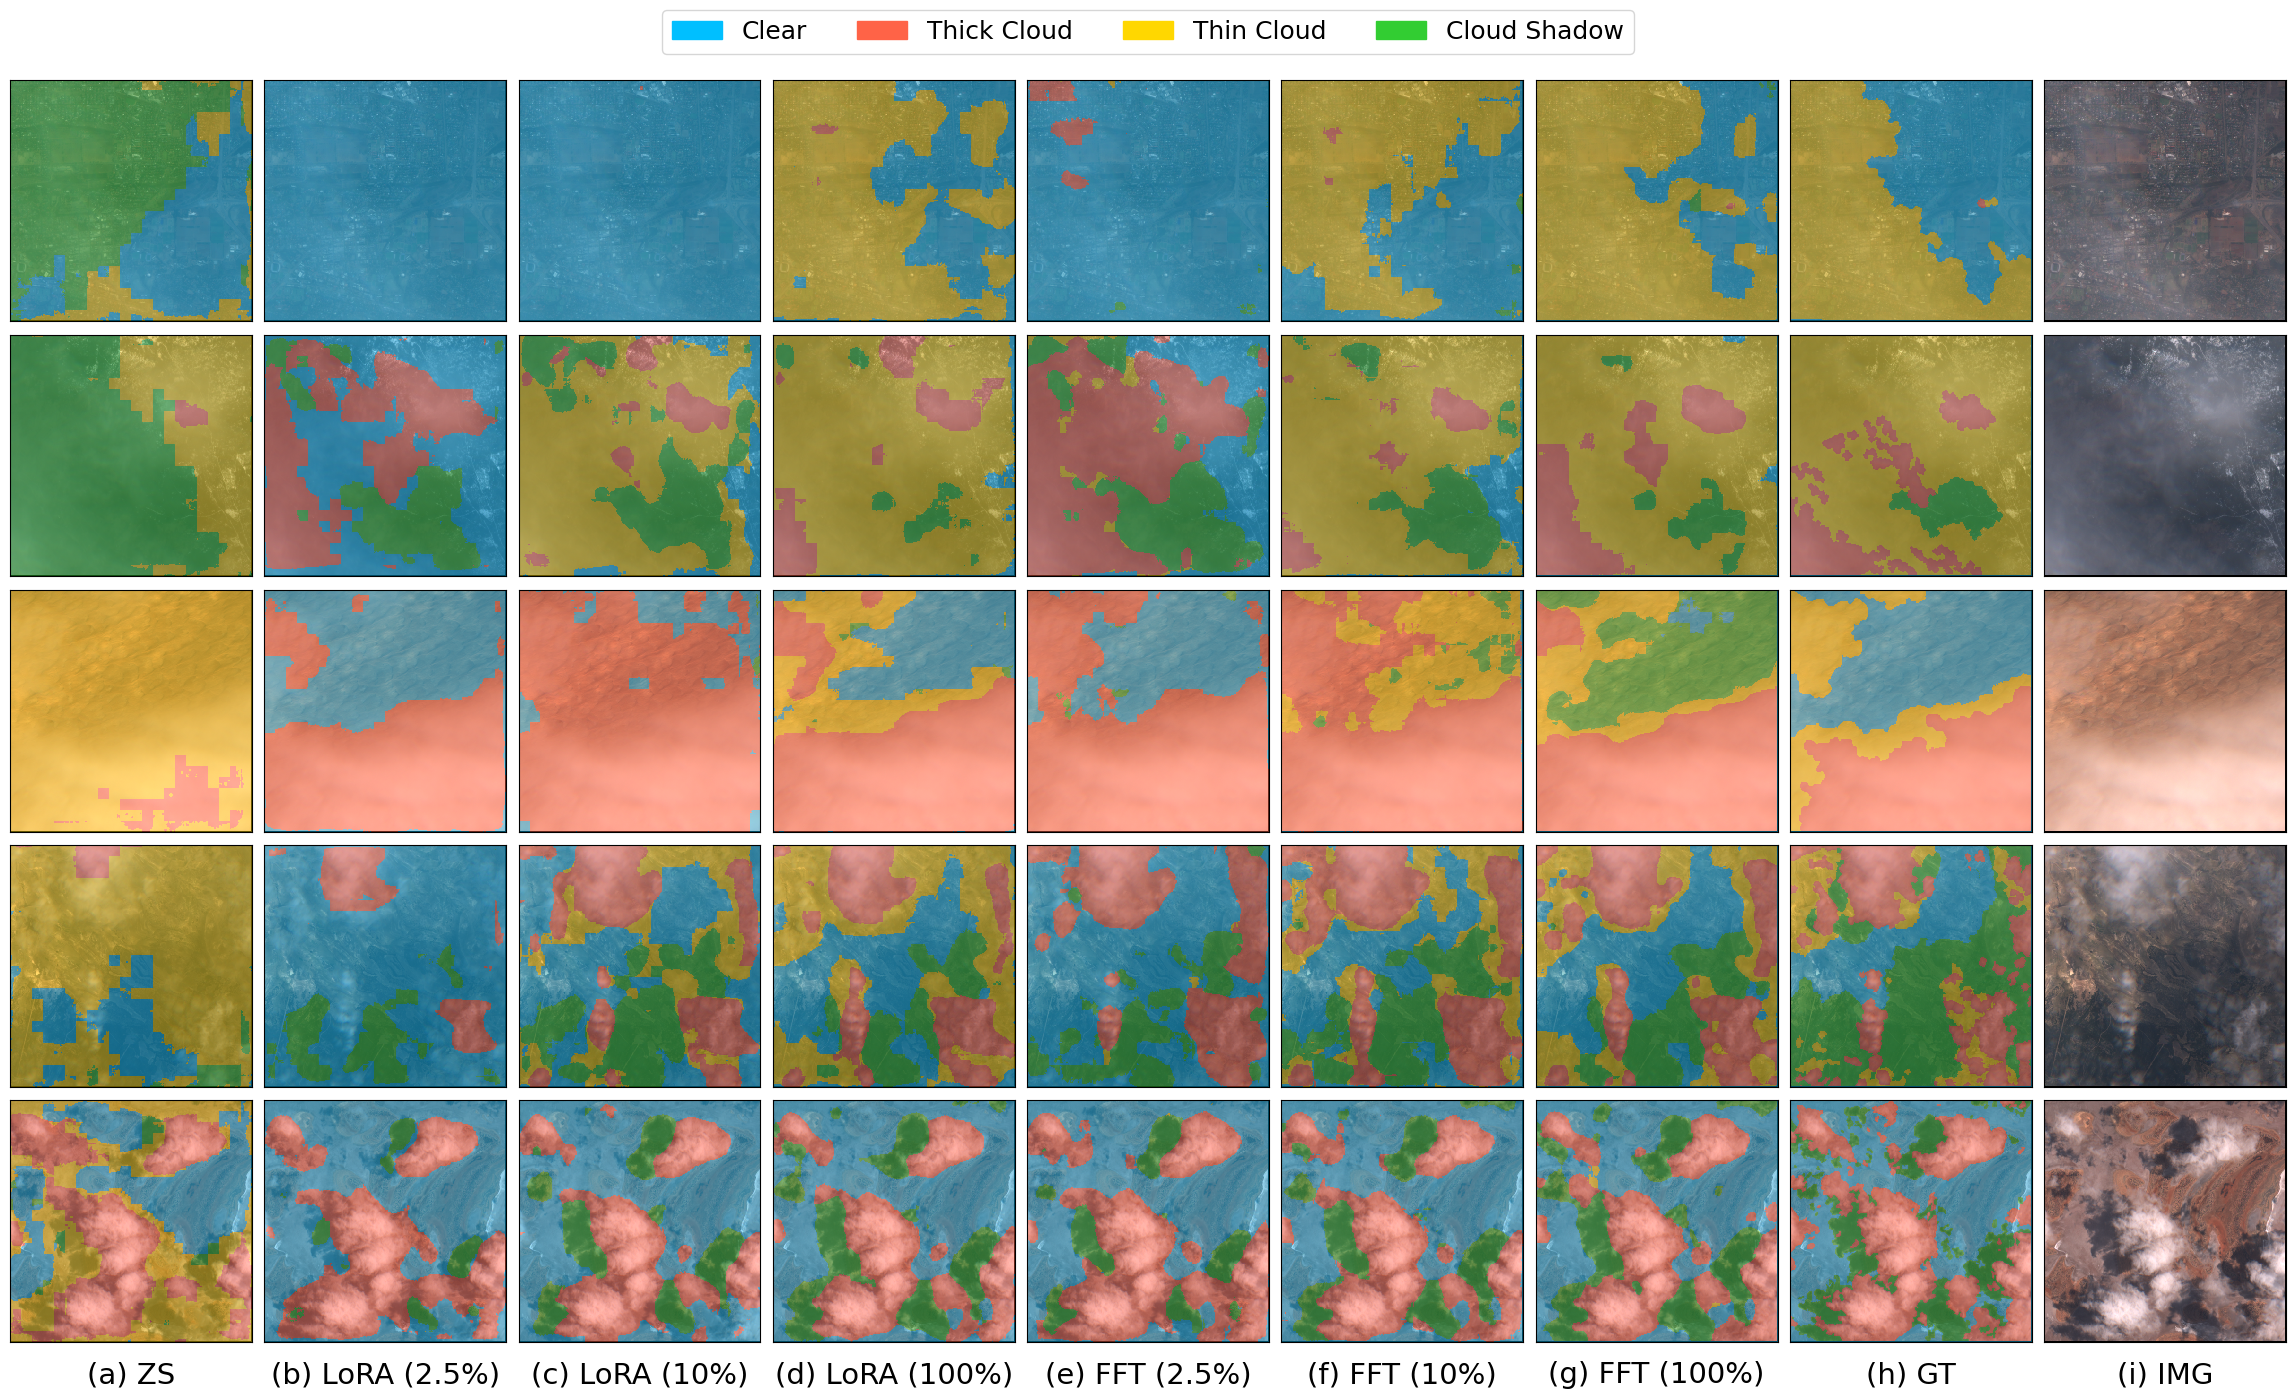

In [160]:
# Cell 4: Plot

plot_clipseg_overlay_grid(
    base_root=BASE_ROOT,
    gt_dir=GT_DIR,
    img_dir=IMG_DIR,

    selected_ids=_selected_now,
    n_rows=N_ROWS,

    lora_pcts=("2.5", "10", "100"),
    fft_pcts=("2.5", "10", "100"),

    class_colors=CLASS_COLORS,
    class_names=CLASS_NAMES,
    overlay_alpha=0.42,
    ignore_labels=IGNORE_LABELS,

    show_legend=True,
    legend_loc="lower center",
    legend_ncol=4,
    legend_fontsize=18,

    figsize_per_cell=(3, 3),  # tweak figure size
    raw_image_title="image",
    gt_title="ground truth",

    use_ax_annotate_for_headers=True,
    header_annotate_xy=(0.5, -0.08),   # <- you asked for annotate control
    header_fontsize=21,

    row_label_mode=None,
    row_label_fontsize=9,
    row_label_rotation=90,

    show_ticks=SHOW_TICKS,
    x_ticks=X_TICKS,
    y_ticks=Y_TICKS,
    tick_fontsize=7,

    global_xlabel=GLOBAL_XLABEL,
    global_ylabel=GLOBAL_YLABEL,

    sup_title=None,
    sup_title_fontsize=14,

    # Leave room for title + legend
    tight_layout_rect=(0, 0.06, 1, 0.95),
)